# Gene Expression Peak-Trough analysis using Polar Plots

April 8, 2024

Analyze the chromatin at genes during peak and trough gene expression.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

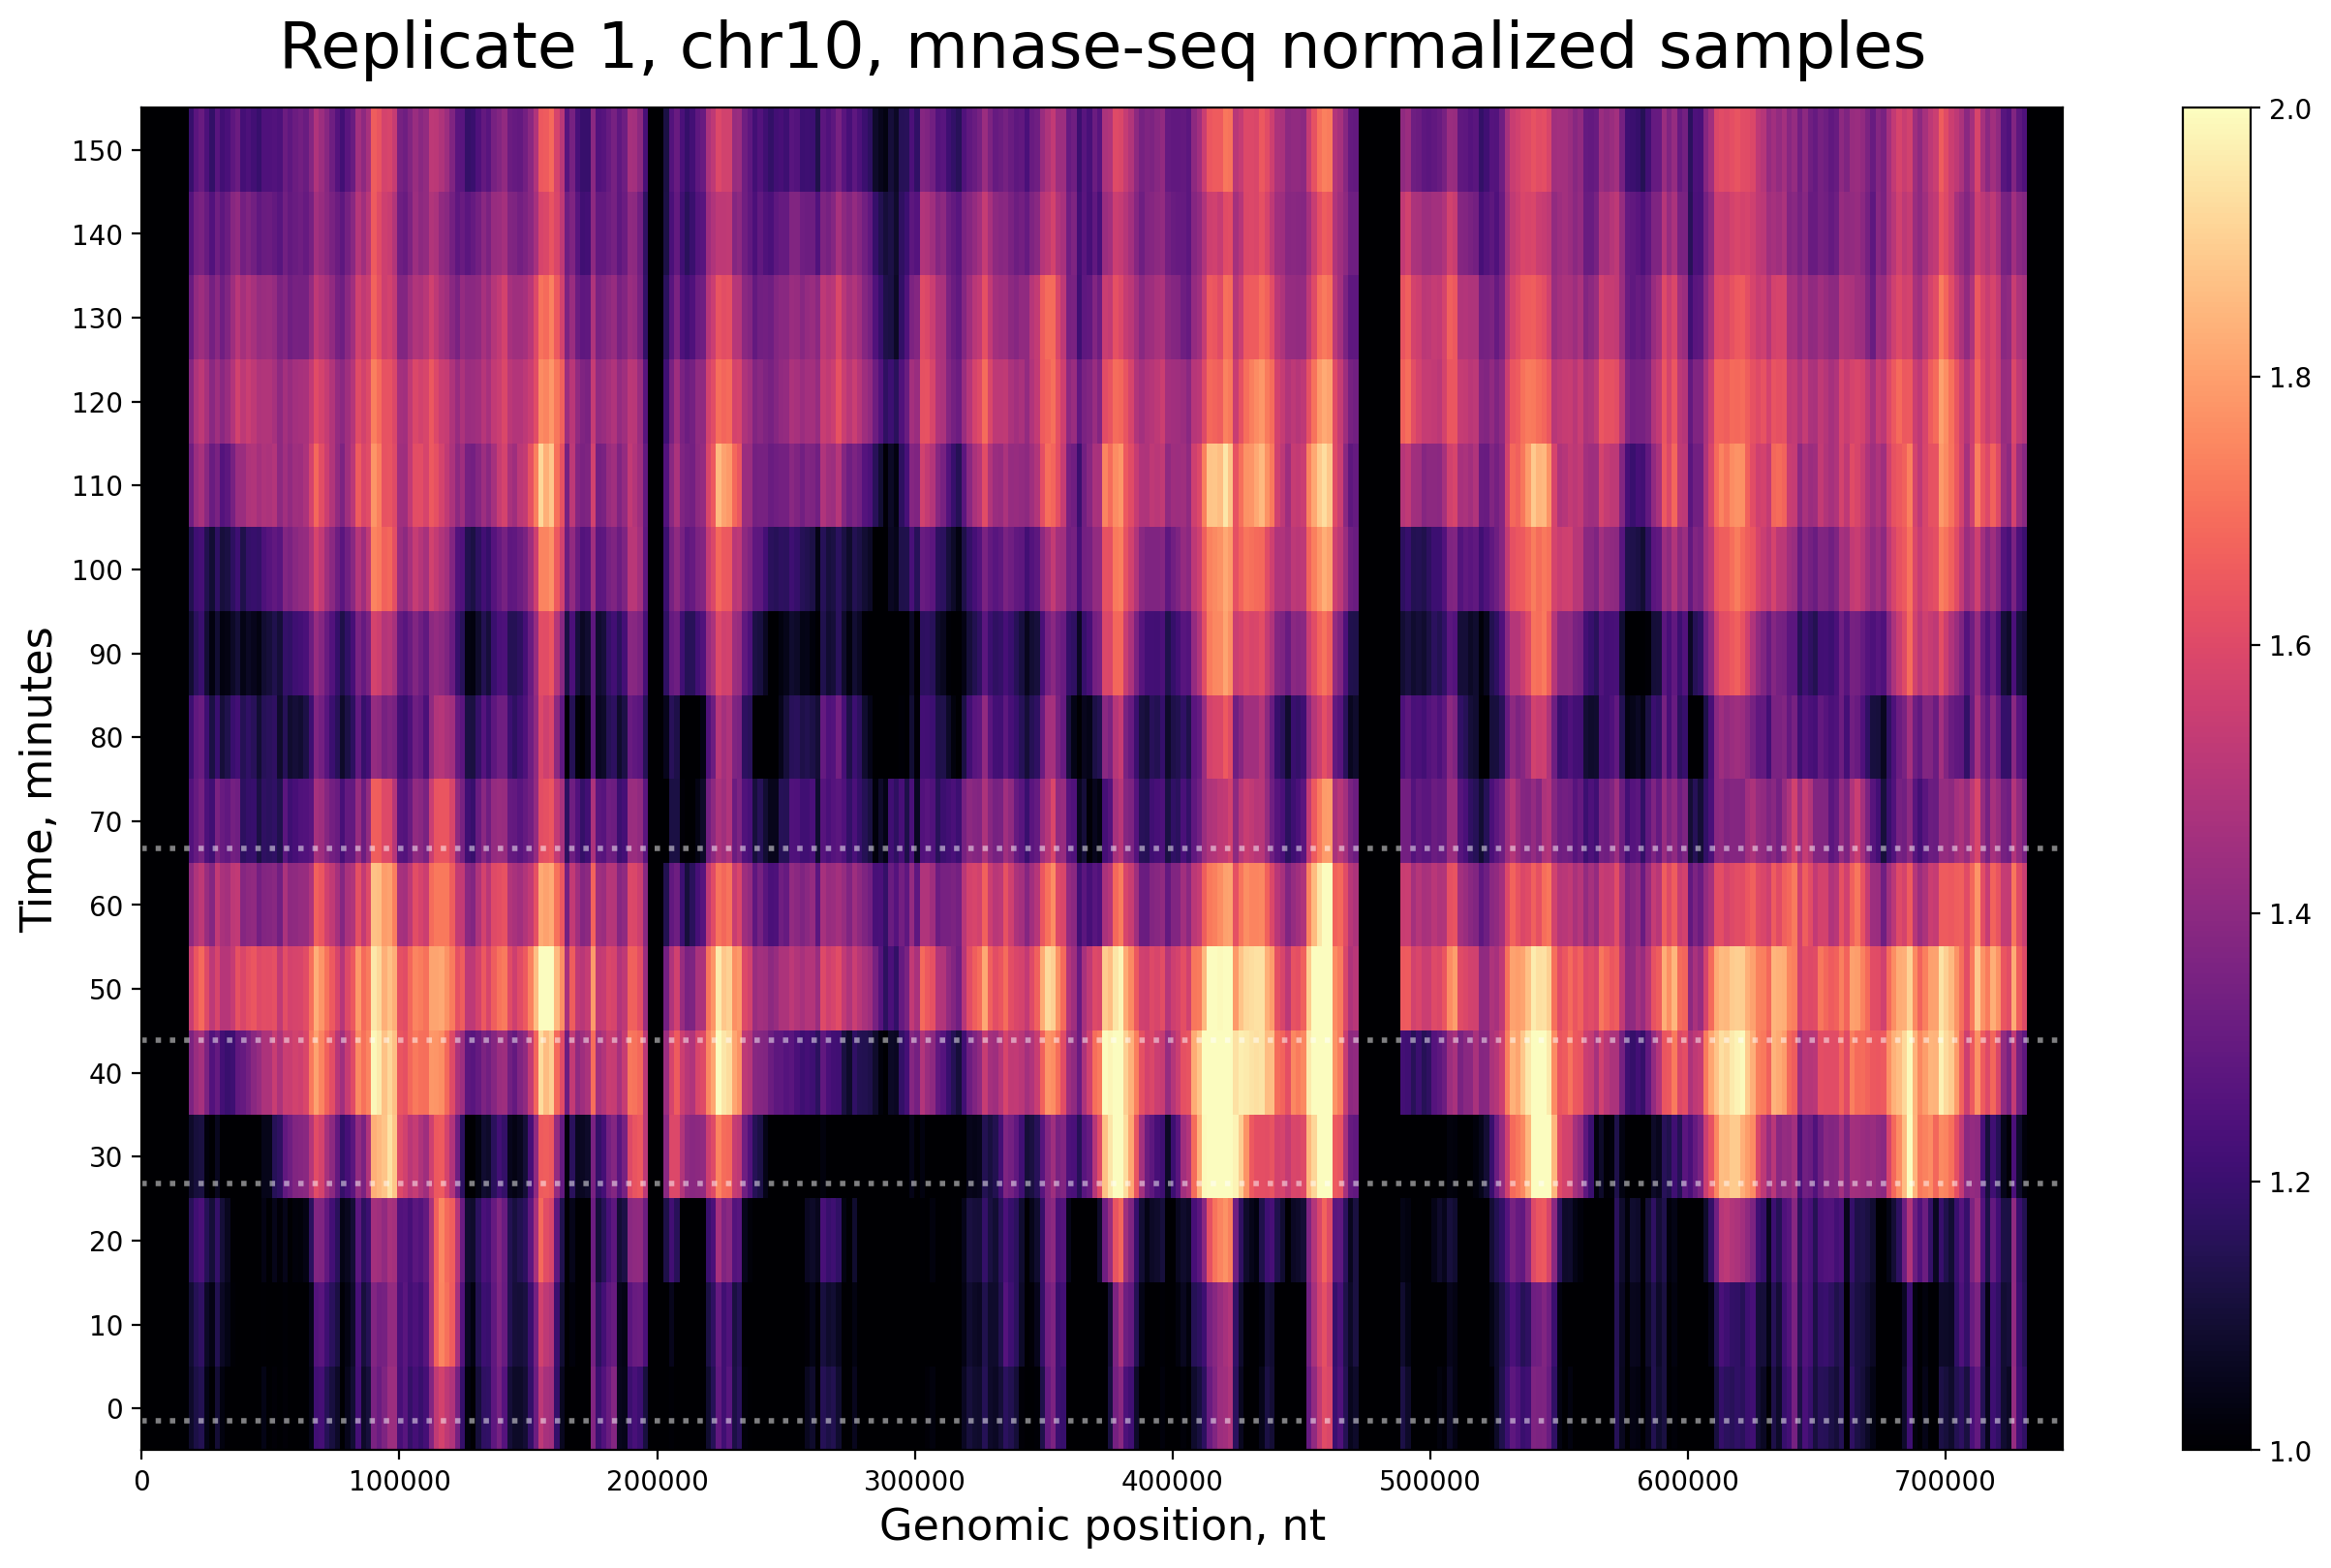

In [6]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

# Compute replication timing profile for both replicates

Compute the 10k bin curves for all genes, normalize the occupancy within the first cell cycle length, then compute the time in which the occupancy reaches a specified threshold (currently 75%) for each gene. The time in which this threshold is met is the replication timing.

Perform for both genes, compute the correlation and take the average.


In [141]:
mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.915


In [142]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:22.560


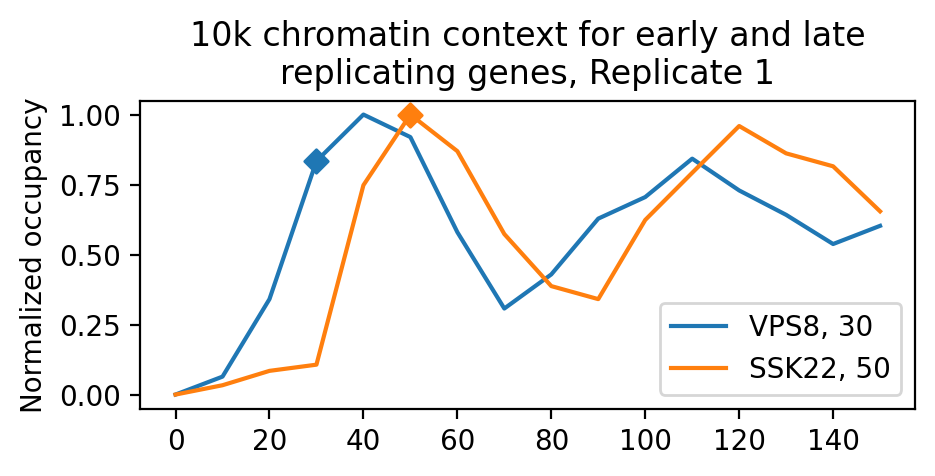

In [301]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

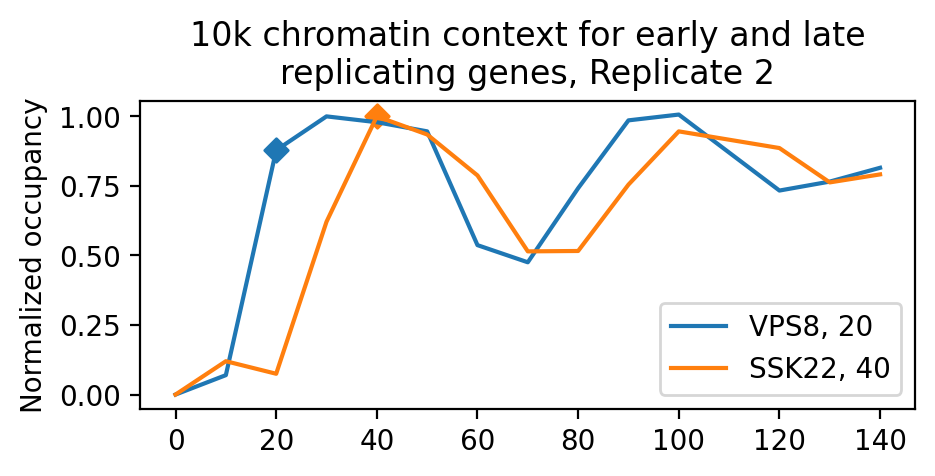

In [302]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [224]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

In [238]:
# We have where G1 should start (w/o recovery) and the length of the cell cycle
# so let's normalize based on translating to the that G1 start
# then divide by the cell cycle length

mnase_analysis_rep1.normalize_replication_timing_by_cell_cycle_parameters()
mnase_analysis_rep2.normalize_replication_timing_by_cell_cycle_parameters()

Text(0.5, 0.98, 'Distribution of replication timing')

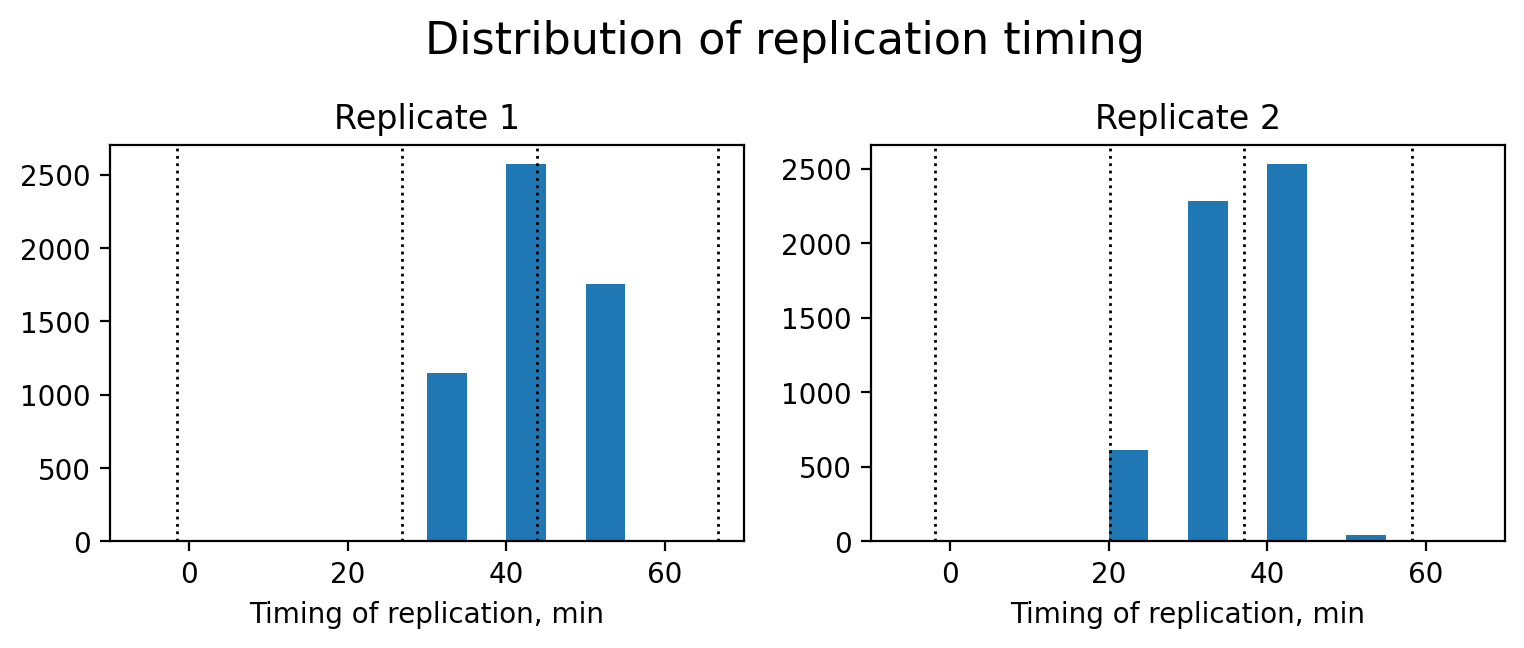

In [303]:
bins = np.arange(0, 70, 5)-5

plt.figure(figsize=(9, 3))
plt.subplots_adjust(top=0.77)

plt.subplot(1, 2, 1)
plt.hist(mnase_analysis_rep1.repl_timing_df, bins=bins)

def plot_lines(lines):
    for line in lines:
        plt.axvline(line, c='black', lw=1, ls='dotted')

plot_lines([
    mnase_analysis_rep1.g1_recovery_would_start_here,
    mnase_analysis_rep1.first_s_start,
    mnase_analysis_rep1.first_s_end,
    mnase_analysis_rep1.end_of_first_lambd,
])

plt.xlim(-10, 70)
plt.title("Replicate 1")
plt.xlabel("Timing of replication, min")

plt.subplot(1, 2, 2)
plt.hist(mnase_analysis_rep2.repl_timing_df, bins=bins)

plot_lines([
    mnase_analysis_rep2.g1_recovery_would_start_here,
    mnase_analysis_rep2.first_s_start,
    mnase_analysis_rep2.first_s_end,
    mnase_analysis_rep2.end_of_first_lambd,
])

plt.xlim(-10, 70)
plt.title("Replicate 2")
plt.xlabel("Timing of replication, min")

plt.suptitle("Distribution of replication timing", fontsize=16)

In [262]:
merged_replication_timing = pd.DataFrame(mnase_analysis_rep1.normalized_timing, columns=['repl_timing1']).join(
    pd.DataFrame(mnase_analysis_rep2.normalized_timing, columns=['repl_timing2']))
merged_replication_timing['mean'] = merged_replication_timing.mean(axis=1)

([], [])

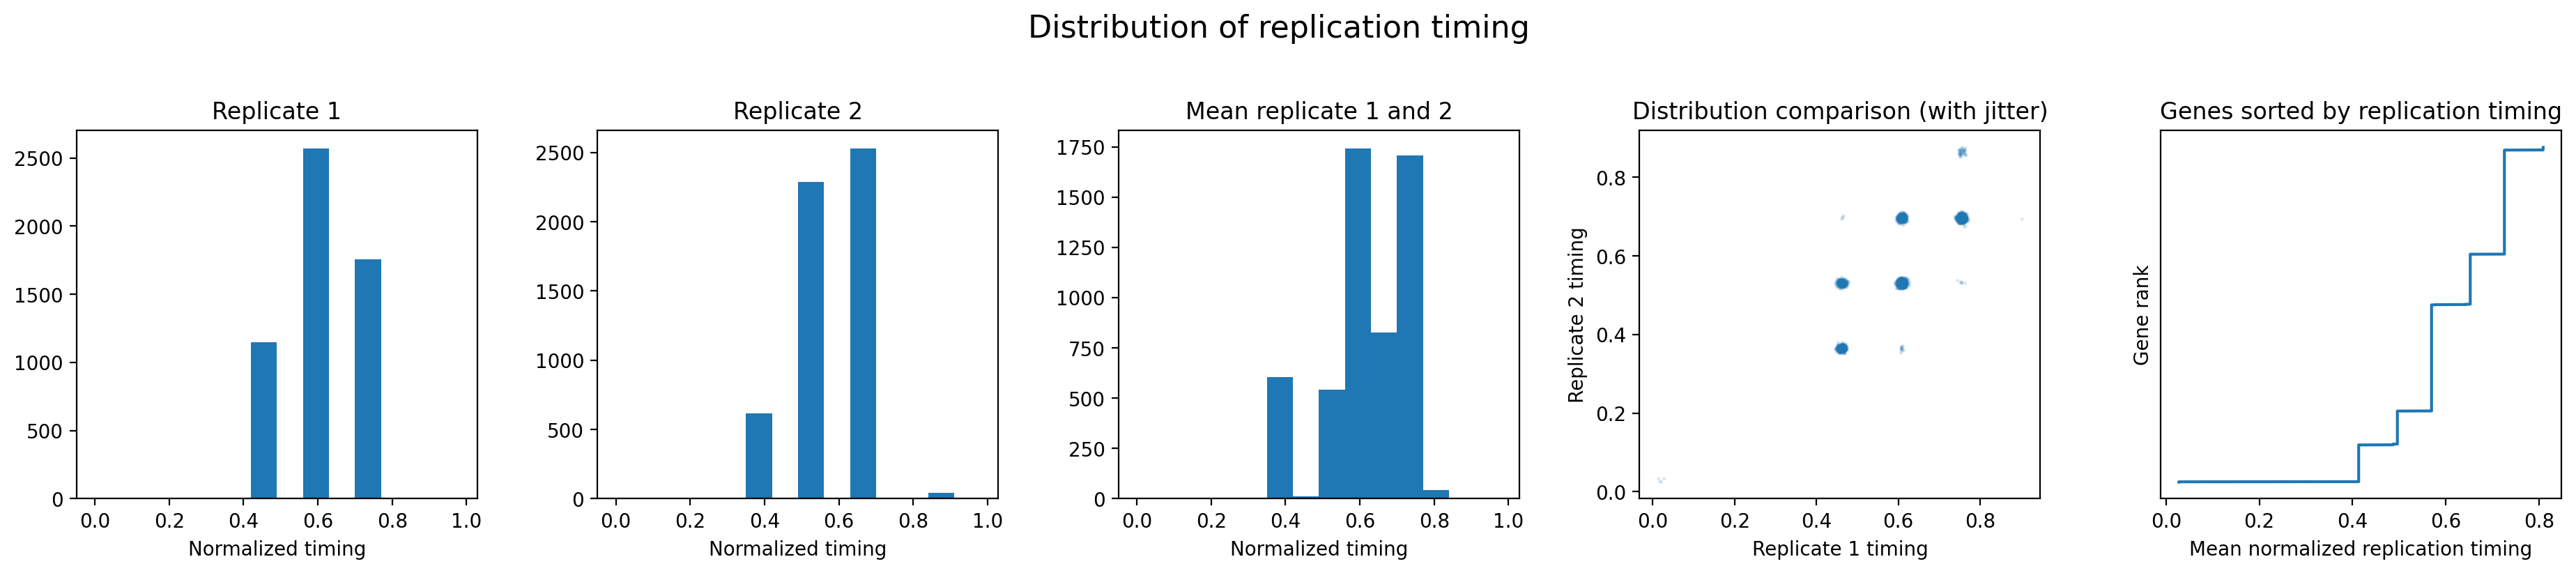

In [308]:

bins = np.arange(0, 1, 0.07)

plt.figure(figsize=(23, 4))
plt.subplots_adjust(top=0.77, wspace=0.3)

plt.subplot(1, 5, 1)
plt.hist(merged_replication_timing.repl_timing1, bins=bins)
plt.title("Replicate 1")
plt.xlabel("Normalized timing")

plt.subplot(1, 5, 2)
plt.hist(merged_replication_timing.repl_timing2, bins=bins)
plt.title("Replicate 2")
plt.xlabel("Normalized timing")

plt.subplot(1, 5, 3)
plt.hist(merged_replication_timing['mean'], bins=bins)
plt.title("Mean replicate 1 and 2")
plt.xlabel("Normalized timing")

plt.suptitle("Distribution of replication timing", fontsize=16)

plt.subplot(1, 5, 4)
from scipy.stats.distributions import norm

n = len(merged_replication_timing)
x_jitter = norm.rvs(loc=0, scale=0.005, size=n)
y_jitter = norm.rvs(loc=0, scale=0.005, size=n)

plt.scatter(merged_replication_timing.repl_timing1 + x_jitter, 
            merged_replication_timing.repl_timing2 + y_jitter,
           s=1, alpha=0.1)
plt.xlabel("Replicate 1 timing")
plt.ylabel("Replicate 2 timing")
plt.title("Distribution comparison (with jitter)")

plt.subplot(1, 5, 5)
x = np.arange(n)
plt.plot(merged_replication_timing.sort_values('mean')['mean'], x)
plt.title("Genes sorted by replication timing")
plt.xlabel("Mean normalized replication timing")
plt.ylabel("Gene rank")
plt.yticks([])

In [282]:
merged_replication_timing.to_csv('datasets/computed_mnase/replication_timing_10k.csv')

In [309]:
# Load the F images, currently we have them ready to plot in the promoter analysis
# but we will move them to its own class

from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [310]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.135
1001/5574 - 00:00:07.435
2001/5574 - 00:00:13.404
3001/5574 - 00:00:19.215
4001/5574 - 00:00:25.011
5001/5574 - 00:00:30.780


In [311]:
promoter_analysis.correct_f_images_by_strand()

In [334]:
strand_corrected_f_images = promoter_analysis.strand_corrected_f_images

In [357]:
# The f images are in a numpy array so keep track of the indices
gene_indices = promoter_analysis.geneset[['gene']].copy()
gene_indices['gene_index'] = np.arange(len(gene_indices))

# Replication timing is a subset, so let's subset the f images
gene_indices = gene_indices.loc[merged_replication_timing.index]
repl_timing = gene_indices.join(merged_replication_timing[['mean']])

sc_f_imgs_with_rep = strand_corrected_f_images[gene_indices.gene_index.values]

# Reset the gene index because we have now subsetted
repl_timing['gene_index'] = np.arange(len(repl_timing))

In [358]:
sc_f_imgs_with_rep.shape

(5482, 227, 8, 25)

In [568]:
# Now we have the indices and the replication timing, let's plot the 
# top 500 genes in aggregate and the lower 500 genes

repl_timing = repl_timing.sort_values('mean')

k = 500
top_500_early = repl_timing.iloc[0:k]
bottom_500_late = repl_timing.iloc[-k:]

In [570]:
top_500_early_imgs_aggregated = sc_f_imgs_with_rep[top_500_early.gene_index].mean(axis=0)
bottom_500_late_imgs_aggregated = sc_f_imgs_with_rep[bottom_500_late.gene_index].mean(axis=0)

In [571]:
# Let's plot the aggreagete plots through various segments of the cell cycle
# CG1:
config = load_yl_rg1_vst_config(1)

cg1_indices = config.get_Hpositions_for_phase('CG1')
dg1_indices = config.get_Hpositions_for_phase('DG1')
postg1_indices = config.get_Hpositions_for_phase('postG1')

def subset_the_indices(indices, size):
    subset_indices = np.linspace(0, len(indices)-1, size).astype(int)
    return indices[subset_indices]

n = 10
cg1_indices_subset = subset_the_indices(cg1_indices, n)
dg1_indices_subset = subset_the_indices(dg1_indices, n)
postg1_indices_subset = subset_the_indices(postg1_indices, n)

In [595]:
# Plot CG1 and DG1 and PostG1
# Compare top 500 and bottom 500 replication timing genes

def plot_phase_subset(aggregate_imgs1, aggregate_imgs2,
                      subset_indices, phase):
    phase_imgs1 = aggregate_imgs1[subset_indices]
    phase_imgs2 = aggregate_imgs2[subset_indices]
    n = len(phase_imgs1)

    fig, axs = plt.subplots(n, 3, figsize=(5, 5))
    plt.subplots_adjust(wspace=0.05)
    
    for i in range(n):
        img1 = phase_imgs1[i]
        img2 = phase_imgs2[i]
        
        ax_row = axs[i]
        
        ax = ax_row[0]
        ax.imshow(img1, origin='lower', cmap='magma_r', vmax=20, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0: ax.set_title(f"Early {k}")
        
        ax = ax_row[1]
        ax.imshow(img2, origin='lower', cmap='magma_r', vmax=20, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0: ax.set_title(f"Late {k}")
            
        ax = ax_row[2]
        im = ax.imshow(img1-img2, origin='lower', cmap='RdBu_r', vmax=1, vmin=-1,
                  aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])

        if i == 0: ax.set_title(f"Difference\nEarly-Late")

    plt.suptitle(phase)

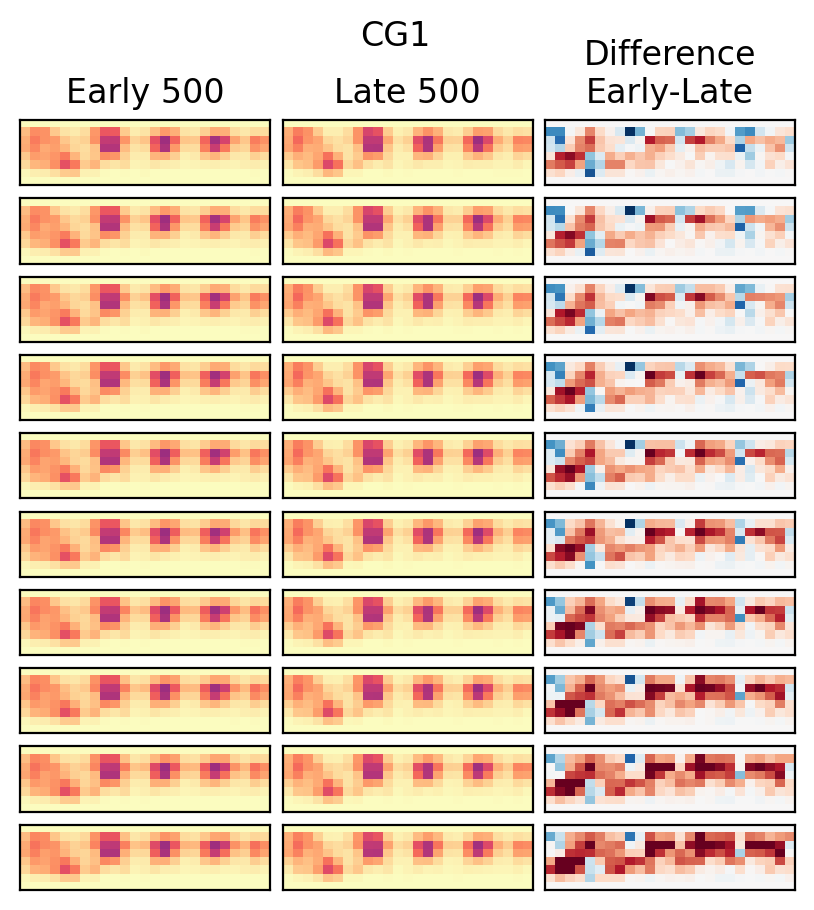

In [596]:
plot_phase_subset(top_500_early_imgs_aggregated, bottom_500_late_imgs_aggregated,
                  cg1_indices_subset, phase="CG1")


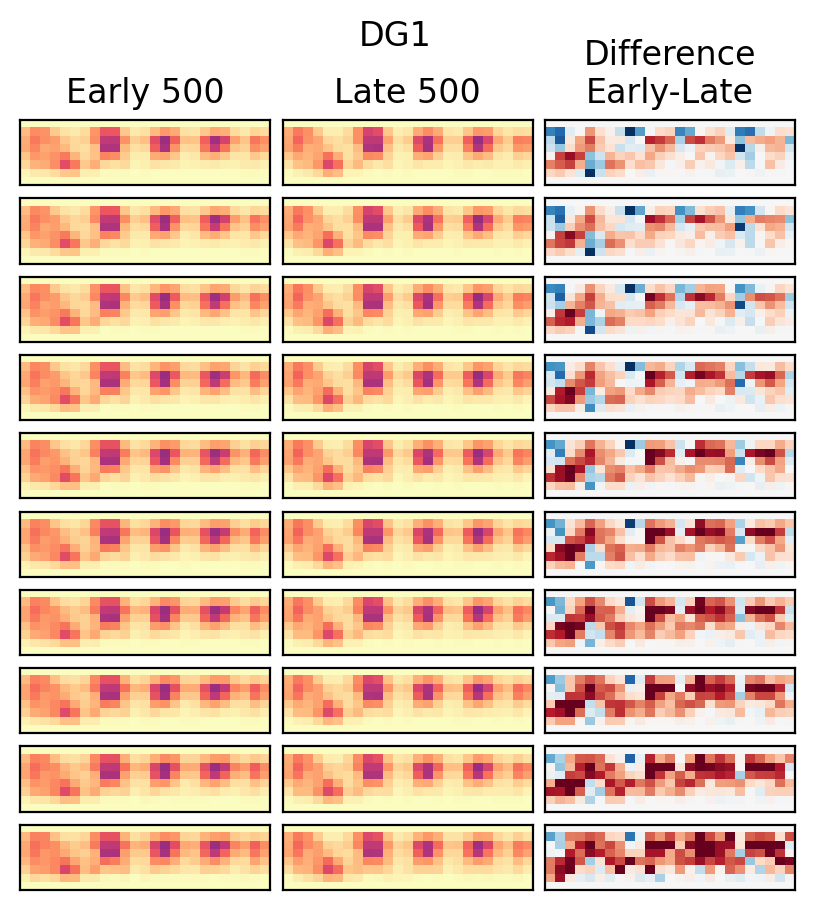

In [597]:
plot_phase_subset(top_500_early_imgs_aggregated, bottom_500_late_imgs_aggregated,
                  dg1_indices_subset, phase="DG1")


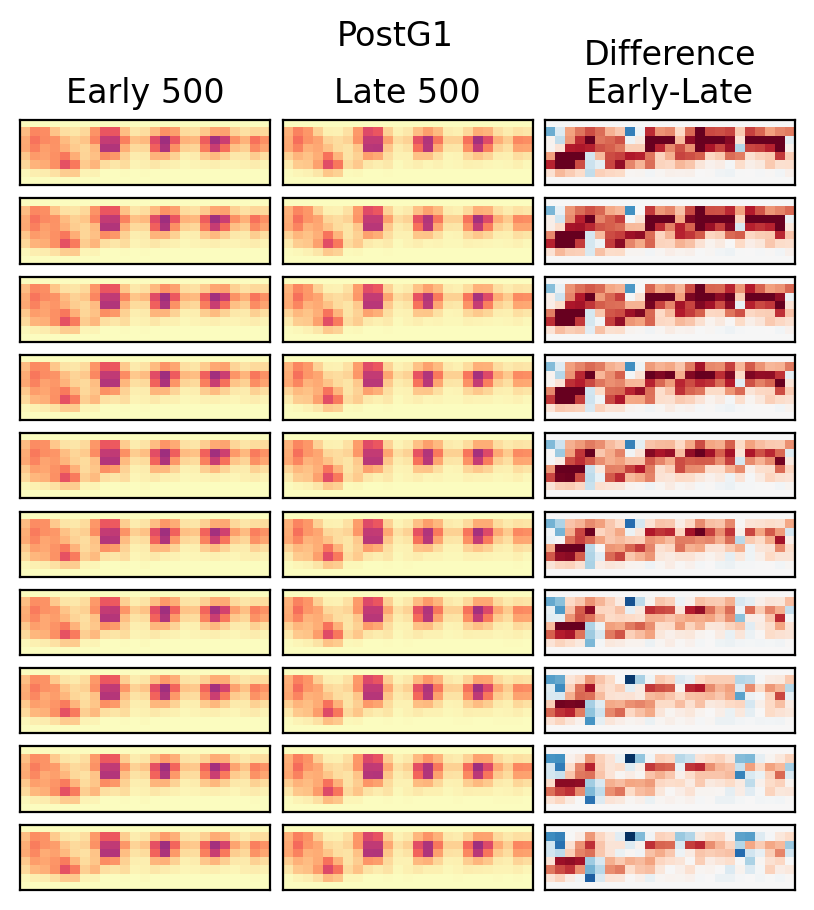

In [598]:
plot_phase_subset(top_500_early_imgs_aggregated, bottom_500_late_imgs_aggregated,
                  postg1_indices_subset, phase="PostG1")


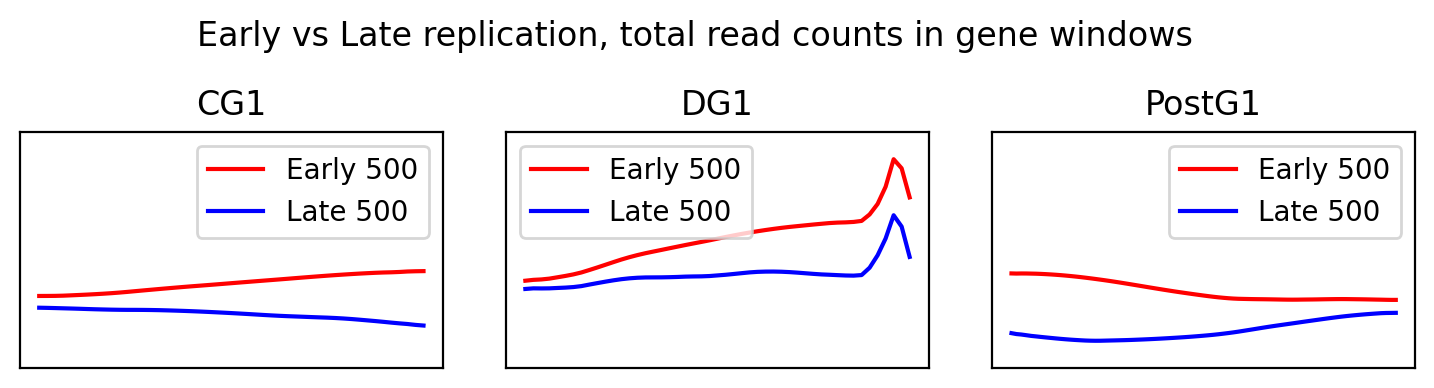

In [586]:

fig, axs = plt.subplots(1, 3, figsize=(9, 2))

indices = np.concatenate([cg1_indices, dg1_indices, postg1_indices])
all_top_values = top_500_imgs_aggregated[indices].sum(axis=1).sum(axis=1)
all_bottom_values = bottom_500_imgs_aggregated[indices].sum(axis=1).sum(axis=1)

all_values = np.concatenate([all_top_values, all_bottom_values])

ymin = all_values.min()
ymax = all_values.max()
ydelta = ymax-ymin
ylim = ymin-ydelta*0.15, ymax+ydelta*0.15

def plot_phase_sum(ax, indices, phase):
    ax.plot(top_500_early_imgs_aggregated[indices].sum(axis=1).sum(axis=1), 
            label=f"Early {k}", c='red')
    ax.plot(bottom_500_late_imgs_aggregated[indices].sum(axis=1).sum(axis=1),
            label=f"Late {k}",
           c='blue')
    ax.set_title(phase)
    ax.legend()
    ax.set_ylim((*ylim))
    ax.set_xticks([])
    ax.set_yticks([])
    
plot_phase_sum(axs[0], cg1_indices, 'CG1')
plot_phase_sum(axs[1], dg1_indices, 'DG1')
plot_phase_sum(axs[2], postg1_indices, 'PostG1')
plt.suptitle("Early vs Late replication, total read counts in gene windows")
plt.subplots_adjust(top=0.7, wspace=0.15)

In [606]:
early_gene_example = sc_f_imgs_with_rep[top_500_early.gene_index[0]]
late_gene_example = sc_f_imgs_with_rep[bottom_500_late.gene_index[-10]]


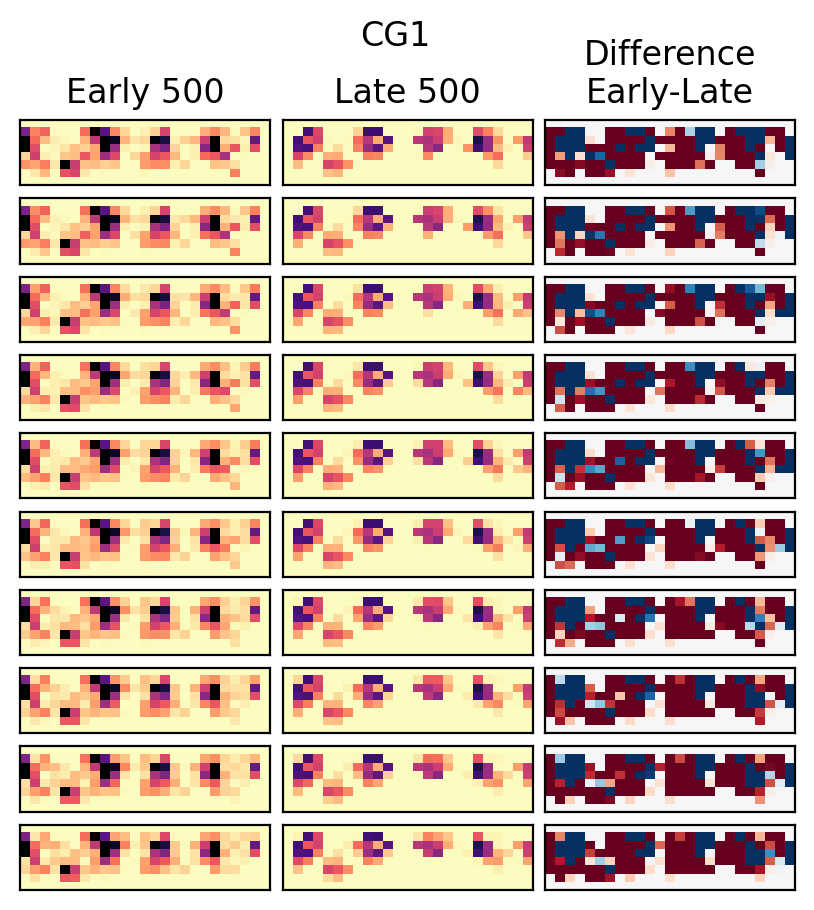

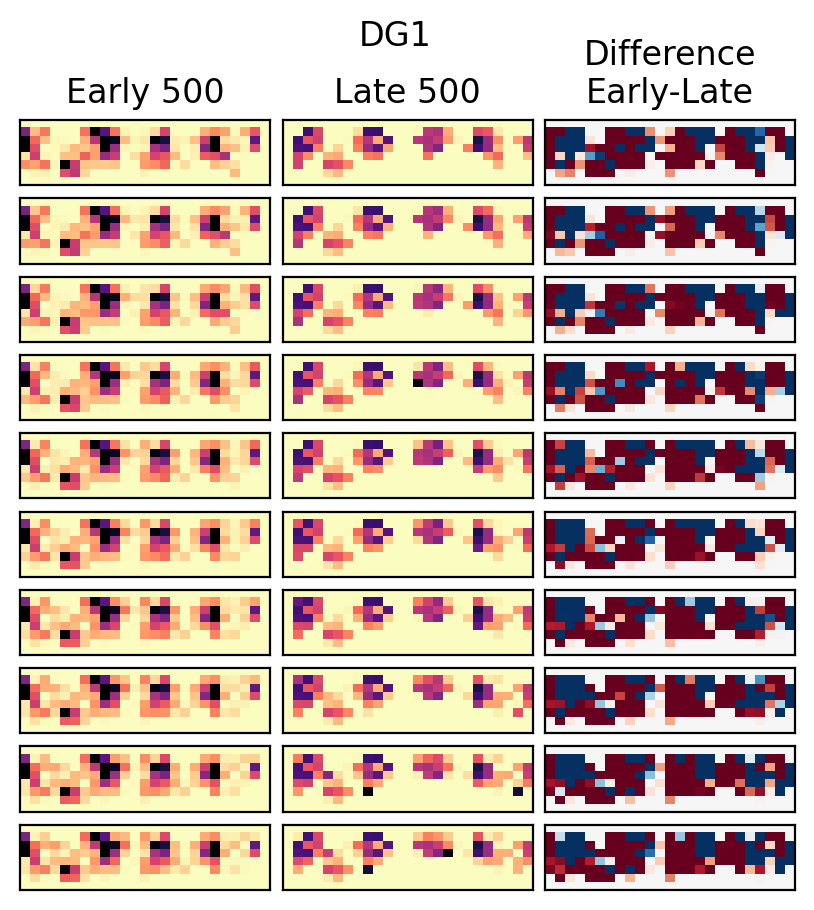

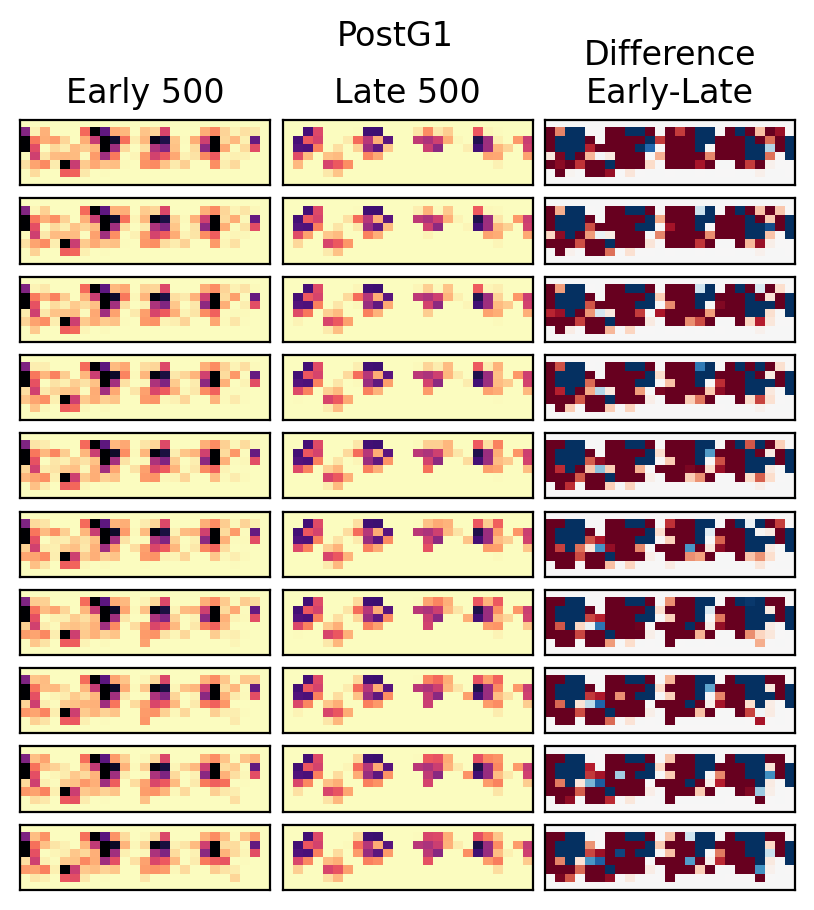

In [612]:

plot_phase_subset(early_gene_example, late_gene_example,
                  cg1_indices_subset, phase="CG1")

plot_phase_subset(early_gene_example, late_gene_example,
                  dg1_indices_subset, phase="DG1")


plot_phase_subset(early_gene_example, late_gene_example,
                  postg1_indices_subset, phase="PostG1")
